#  Praktikum Machine Learning
## Pertemuan 1: Pengenalan Python untuk ML dan Setup Environment

* **Nama**: Ardian Syaputra
* **NIM**: 105841107823

---

## 🛠️ 1. Setup Environment
Verifikasi instalasi Python dan environment yang digunakan untuk praktikum Machine Learning:

![Setup Environment](image.png)

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine

In [15]:
# Set seed agar hasil acak selalu konsisten
np.random.seed(42)

# 1. Array 20 angka random antara 0-100
arr_20 = np.random.randint(0, 101, 20)
print("Array 20 angka random:\n", arr_20)

# 2. Hitung statistik dasar
print("\n=== Statistik Array ===")
print(f"Mean: {np.mean(arr_20):.2f}")
print(f"Median: {np.median(arr_20):.2f}")
print(f"Standard Deviation: {np.std(arr_20):.2f}")
print(f"Min: {np.min(arr_20)}")
print(f"Max: {np.max(arr_20)}")

# 3. Matrix 5x5 dengan angka random
matrix_5x5 = np.random.randint(1, 50, size=(5, 5))
print("\n=== Matrix 5x5 ===\n", matrix_5x5)

# 4. Transpose matrix
matrix_transpose = matrix_5x5.T
print("\n=== Transpose Matrix ===\n", matrix_transpose)

# 5. Determinant matrix
det_matrix = np.linalg.det(matrix_5x5)
print(f"\nDeterminant Matrix: {det_matrix:.2f}")

Array 20 angka random:
 [51 92 14 71 60 20 82 86 74 74 87 99 23  2 21 52  1 87 29 37]

=== Statistik Array ===
Mean: 53.10
Median: 56.00
Standard Deviation: 31.47
Min: 1
Max: 99

=== Matrix 5x5 ===
 [[ 2 21 33 12 22]
 [44 25 49 27 42]
 [28 16 15 47 44]
 [ 3 37  7 21  9]
 [39 18  4 25 14]]

=== Transpose Matrix ===
 [[ 2 44 28  3 39]
 [21 25 16 37 18]
 [33 49 15  7  4]
 [12 27 47 21 25]
 [22 42 44  9 14]]

Determinant Matrix: 3810291.00


In [16]:
# Buat dataset 10 mahasiswa
data_mahasiswa = {
    'NIM': ['105841107823', '105841107824', '105841107825', '105841107826', '105841107827',
            '105841107828', '105841107829', '105841107830', '105841107831', '105841107832'],
    'Nama': ['Ardian', 'Budi', 'Citra', 'Deni', 'Eka', 'Fajar', 'Gita', 'Hadi', 'Indah', 'Joko'],
    'Nilai_Matematika': [85, 78, 92, 65, 88, 95, 70, 82, 90, 75],
    'Nilai_Fisika': [88, 72, 90, 70, 85, 92, 68, 80, 89, 78],
    'Nilai_Kimia': [82, 80, 94, 68, 84, 96, 72, 85, 91, 70]
}

df_mhs = pd.DataFrame(data_mahasiswa)

# 1. Rata-rata nilai per mata kuliah
print("=== Rata-rata Nilai per Mata Kuliah ===")
print(df_mhs[['Nilai_Matematika', 'Nilai_Fisika', 'Nilai_Kimia']].mean())

# 2. Rata-rata nilai per mahasiswa
df_mhs['Rata_Rata'] = df_mhs[['Nilai_Matematika', 'Nilai_Fisika', 'Nilai_Kimia']].mean(axis=1)
print("\n=== Data Mahasiswa dengan Rata-rata ===")
print(df_mhs[['NIM', 'Nama', 'Rata_Rata']])

# 3. 5 mahasiswa dengan nilai tertinggi
top_5 = df_mhs.sort_values(by='Rata_Rata', ascending=False).head(5)
print("\n=== Top 5 Mahasiswa Nilai Tertinggi ===")
print(top_5[['NIM', 'Nama', 'Rata_Rata']])

# 4. Filter mahasiswa dengan rata-rata >= 80
lulus_80 = df_mhs[df_mhs['Rata_Rata'] >= 80]
print("\n=== Mahasiswa dengan Rata-rata >= 80 ===")
print(lulus_80[['NIM', 'Nama', 'Rata_Rata']])

# 5. Export DataFrame ke file CSV
df_mhs.to_csv('data_mahasiswa.csv', index=False)
print("\nDataFrame berhasil diexport ke file 'data_mahasiswa.csv'")

=== Rata-rata Nilai per Mata Kuliah ===
Nilai_Matematika    82.0
Nilai_Fisika        81.2
Nilai_Kimia         82.2
dtype: float64

=== Data Mahasiswa dengan Rata-rata ===
            NIM    Nama  Rata_Rata
0  105841107823  Ardian  85.000000
1  105841107824    Budi  76.666667
2  105841107825   Citra  92.000000
3  105841107826    Deni  67.666667
4  105841107827     Eka  85.666667
5  105841107828   Fajar  94.333333
6  105841107829    Gita  70.000000
7  105841107830    Hadi  82.333333
8  105841107831   Indah  90.000000
9  105841107832    Joko  74.333333

=== Top 5 Mahasiswa Nilai Tertinggi ===
            NIM    Nama  Rata_Rata
5  105841107828   Fajar  94.333333
2  105841107825   Citra  92.000000
8  105841107831   Indah  90.000000
4  105841107827     Eka  85.666667
0  105841107823  Ardian  85.000000

=== Mahasiswa dengan Rata-rata >= 80 ===
            NIM    Nama  Rata_Rata
0  105841107823  Ardian  85.000000
2  105841107825   Citra  92.000000
4  105841107827     Eka  85.666667
5  10584110

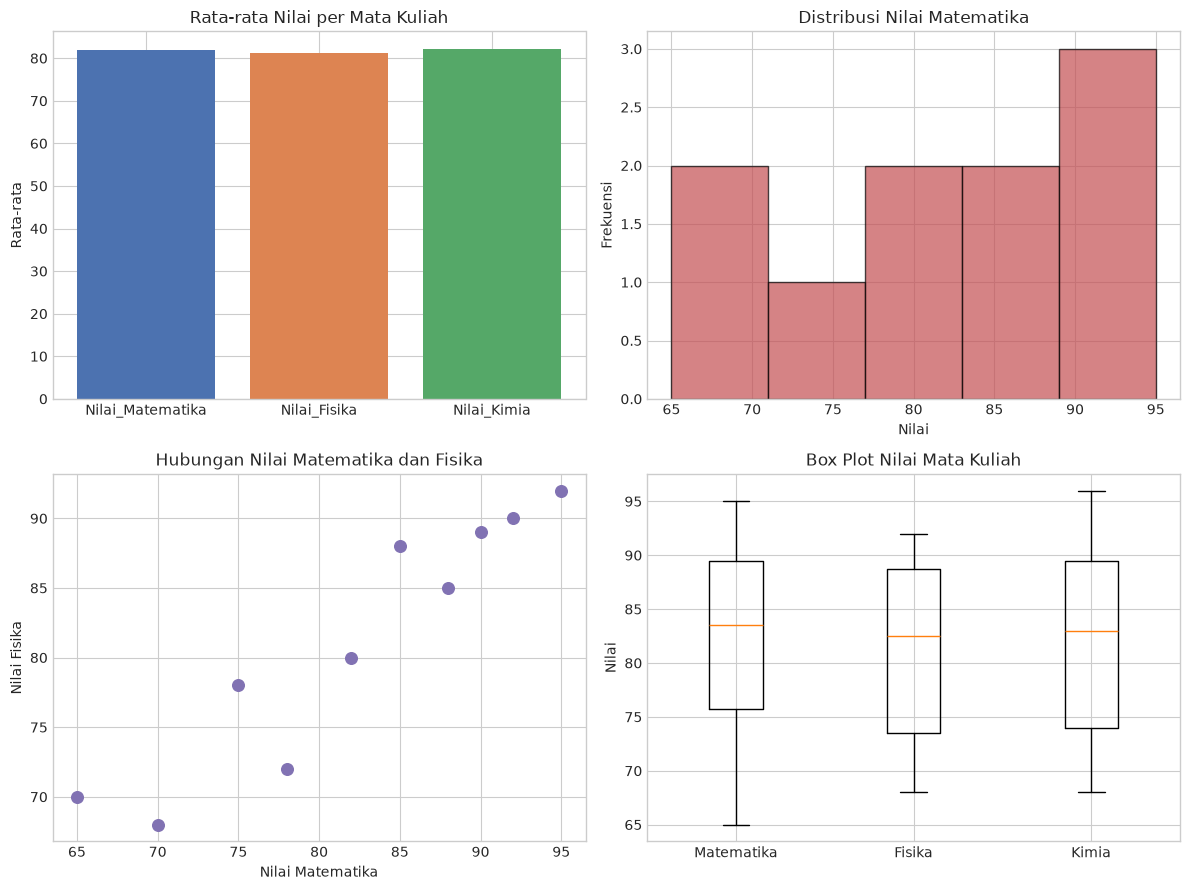

In [17]:
# Set gaya visualisasi
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# 1. Bar chart rata-rata per mata kuliah
mean_matkul = df_mhs[['Nilai_Matematika', 'Nilai_Fisika', 'Nilai_Kimia']].mean()
axes[0, 0].bar(mean_matkul.index, mean_matkul.values, color=['#4C72B0', '#DD8452', '#55A868'])
axes[0, 0].set_title('Rata-rata Nilai per Mata Kuliah')
axes[0, 0].set_ylabel('Rata-rata')

# 2. Histogram distribusi nilai Matematika
axes[0, 1].hist(df_mhs['Nilai_Matematika'], bins=5, color='#C44E52', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribusi Nilai Matematika')
axes[0, 1].set_xlabel('Nilai')
axes[0, 1].set_ylabel('Frekuensi')

# 3. Scatter plot hubungan Matematika vs Fisika
axes[1, 0].scatter(df_mhs['Nilai_Matematika'], df_mhs['Nilai_Fisika'], color='#8172B3', s=70)
axes[1, 0].set_title('Hubungan Nilai Matematika dan Fisika')
axes[1, 0].set_xlabel('Nilai Matematika')
axes[1, 0].set_ylabel('Nilai Fisika')

# 4. Box plot semua nilai mata kuliah
axes[1, 1].boxplot([df_mhs['Nilai_Matematika'], df_mhs['Nilai_Fisika'], df_mhs['Nilai_Kimia']], 
                   tick_labels=['Matematika', 'Fisika', 'Kimia'])
axes[1, 1].set_title('Box Plot Nilai Mata Kuliah')
axes[1, 1].set_ylabel('Nilai')

plt.tight_layout()
plt.show()

=== 10 Baris Pertama Dataset Wine ===
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   
5    14.20        1.76  2.45               15.2      112.0           3.27   
6    14.39        1.87  2.45               14.6       96.0           2.50   
7    14.06        2.15  2.61               17.6      121.0           2.60   
8    14.83        1.64  2.17               14.0       97.0           2.80   
9    13.86        1.35  2.27               16.0       98.0           2.98   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28

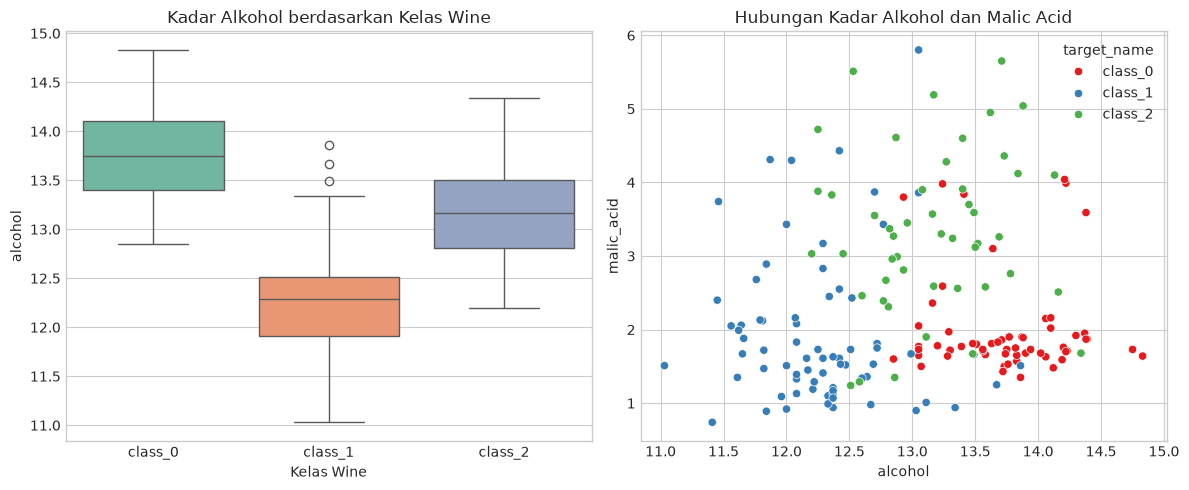

In [18]:
# Load dataset Wine & konversi ke DataFrame
wine = load_wine()
wine_df = pd.DataFrame(data=wine.data, columns=wine.feature_names)
wine_df['target'] = wine.target
wine_df['target_name'] = wine_df['target'].map(lambda x: wine.target_names[x])

# 1. Tampilkan 10 baris pertama
print("=== 10 Baris Pertama Dataset Wine ===")
print(wine_df.head(10))

# 2. Statistik deskriptif
print("\n=== Statistik Deskriptif ===")
print(wine_df.describe())

# 3. Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Visualisasi 1: Boxplot kadar alkohol per kelas
sns.boxplot(x='target_name', y='alcohol', data=wine_df, ax=axes[0], hue='target_name', palette='Set2', legend=False)
axes[0].set_title('Kadar Alkohol berdasarkan Kelas Wine')
axes[0].set_xlabel('Kelas Wine')

# Visualisasi 2: Scatter plot Alcohol vs Malic Acid
sns.scatterplot(x='alcohol', y='malic_acid', hue='target_name', data=wine_df, ax=axes[1], palette='Set1')
axes[1].set_title('Hubungan Kadar Alkohol dan Malic Acid')

plt.tight_layout()
plt.show()